# 01 - Mechanistic Model

Baseline Jinan 2023 case: weather acquisition, load generation, PV and wind generation. Calls functions from `src.data.*`, `src.physics.*`, and `src.visualization.*` only -- no modelling logic is written here (PROJECT_BRIEF.md §25, §1.6).

Battery dispatch and the battery-size optimization sweep (Stage 3) are covered once `src.physics.optimization` is implemented; this notebook currently covers the Stage 2 components only.

In [1]:
%matplotlib inline
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- pulling latest changes...")
        subprocess.run(["git", "pull", "origin", BRANCH], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
import pandas as pd

logging.basicConfig(level=logging.INFO)

from src.config import load_site_config
from src.data.weather import get_processed_weather
from src.physics.load_profile import generate_load_profile
from src.physics.pv_model import compute_pv_generation
from src.physics.wind_model import compute_wind_generation, adjust_wind_speed_to_hub_height
from src.visualization.plotting import (
    plot_annual_profile, plot_representative_week, plot_load_duration_curve,
    plot_monthly_energy, plot_wind_speed_distribution_and_power_curve,
    plot_metric_vs_battery_capacity, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
config = load_site_config("jinan")
config

{'site': {'name': 'jinan',
  'latitude': 36.65,
  'longitude': 117.12,
  'timezone': 'Asia/Shanghai',
  'elevation_m': 51},
 'simulation': {'year': 2023, 'expected_hourly_records': 8760},
 'load': {'target_annual_kwh': 30000,
  'max_hourly_kw': 15,
  'profile_family': 'residential_baseline',
  'random_seed': 42},
 'pv': {'capacity_kwp': 20.0,
  'tilt_deg': 36.65,
  'azimuth_deg': 180.0,
  'system_losses_fraction': 0.14,
  'inverter_efficiency': 0.96},
 'wind': {'rated_power_kw': 10.0,
  'hub_height_m': 15.0,
  'wind_shear_exponent': 0.14,
  'cut_in_mps': 2.5,
  'rated_mps': 11.0,
  'cut_out_mps': 25.0,
  'weather_reference_height_m': 10},
 'battery': {'chemistry': 'LFP',
  'module_capacity_kwh': 15.36,
  'module_rated_power_kw': 12.8,
  'round_trip_efficiency': 0.95,
  'min_soc_fraction': 0.1,
  'max_soc_fraction': 0.95,
  'initial_soc_fraction': 0.5,
  'economic_lifetime_years': 10,
  'project_lifetime_years': 20,
  'installed_cost_eur_per_kwh': 550,
  'cost_sensitivity_eur_per_kwh': 

## Weather data

See `data/README.md` for the NASA POWER API validation findings (time standard, units, wind reference height) this pipeline relies on.

In [2]:
weather = get_processed_weather("jinan", config["simulation"]["year"])
weather.to_csv(TABLES_DIR / "baseline_hourly_weather.csv", index_label="timestamp")
weather.describe()

INFO:src.data.weather:Loading cached processed weather from /home/user/Leonardo-Assignment/data/processed/jinan_2023_weather.csv


,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M,WS10M
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,175.671842,162.004216,73.605250,13.659402,3.790208
std,252.473951,262.093952,99.690847,12.030952,2.023951
min,0.000000,0.000000,0.000000,-20.600000,0.080000
25%,0.000000,0.000000,0.000000,3.190000,2.290000
50%,6.930000,0.000000,8.360000,15.065000,3.400000
75%,310.505000,262.485000,132.192500,23.540000,4.940000
max,985.880000,1057.940000,533.090000,40.090000,13.850000


## Load profile

In [3]:
load = generate_load_profile(
    annual_consumption_kwh=config["load"]["target_annual_kwh"],
    peak_load_kw=config["load"]["max_hourly_kw"],
    year=config["simulation"]["year"],
    timezone=config["site"]["timezone"],
    random_seed=config["load"]["random_seed"],
    profile_family=config["load"]["profile_family"],
)
load.to_csv(TABLES_DIR / "baseline_hourly_load.csv", index_label="timestamp", header=["load_kw"])
print(f"Annual: {load.sum():.0f} kWh, peak: {load.max():.2f} kW, mean: {load.mean():.2f} kW")
load.describe()

INFO:src.physics.load_profile:Generated load profile: annual=30000.0 kWh, peak=8.00 kW, mean=3.425 kW, n=8760


Annual: 30000 kWh, peak: 8.00 kW, mean: 3.42 kW


count    8760.000000
mean        3.424658
std         1.375934
min         1.043992
25%         2.334559
50%         3.342634
75%         4.385053
max         7.996207
Name: load_kw, dtype: float64

## PV generation

In [4]:
pv = compute_pv_generation(
    weather=weather,
    capacity_kwp=config["pv"]["capacity_kwp"],
    latitude=config["site"]["latitude"],
    longitude=config["site"]["longitude"],
    tilt_deg=config["pv"]["tilt_deg"],
    azimuth_deg=config["pv"]["azimuth_deg"],
    system_losses_fraction=config["pv"]["system_losses_fraction"],
    inverter_efficiency=config["pv"]["inverter_efficiency"],
)
print(f"Annual: {pv.sum():.0f} kWh, capacity factor: {pv.sum() / (config['pv']['capacity_kwp'] * len(pv)):.3f}")
pv.describe()

INFO:src.physics.pv_model:Computed PV generation: capacity=20.0 kWp, annual=25693.7 kWh, capacity_factor=0.147


Annual: 25694 kWh, capacity factor: 0.147


count    8760.000000
mean        2.933067
std         4.241213
min         0.000000
25%         0.000000
50%         0.136690
75%         5.182695
max        17.568647
Name: pv_kw, dtype: float64

## Wind generation

In [5]:
wind = compute_wind_generation(
    weather=weather,
    rated_power_kw=config["wind"]["rated_power_kw"],
    reference_height_m=config["wind"]["weather_reference_height_m"],
    hub_height_m=config["wind"]["hub_height_m"],
    shear_exponent=config["wind"]["wind_shear_exponent"],
    cut_in_mps=config["wind"]["cut_in_mps"],
    rated_mps=config["wind"]["rated_mps"],
    cut_out_mps=config["wind"]["cut_out_mps"],
)
print(f"Annual: {wind.sum():.0f} kWh, capacity factor: {wind.sum() / (config['wind']['rated_power_kw'] * len(wind)):.3f}")

pv.to_frame("pv_kw").join(wind.to_frame("wind_kw")).to_csv(
    TABLES_DIR / "baseline_pv_wind_generation.csv", index_label="timestamp"
)
wind.describe()

INFO:src.physics.wind_model:Computed wind generation: rated=10.0 kW, annual=7523.4 kWh, capacity_factor=0.086


Annual: 7523 kWh, capacity factor: 0.086


count    8760.000000
mean        0.858838
std         1.541099
min         0.000000
25%         0.000000
50%         0.235492
75%         0.967862
max        10.000000
Name: wind_kw, dtype: float64

## Required figures (PROJECT_BRIEF.md §27, mechanistic figures 1-6)

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/01_annual_profile.png


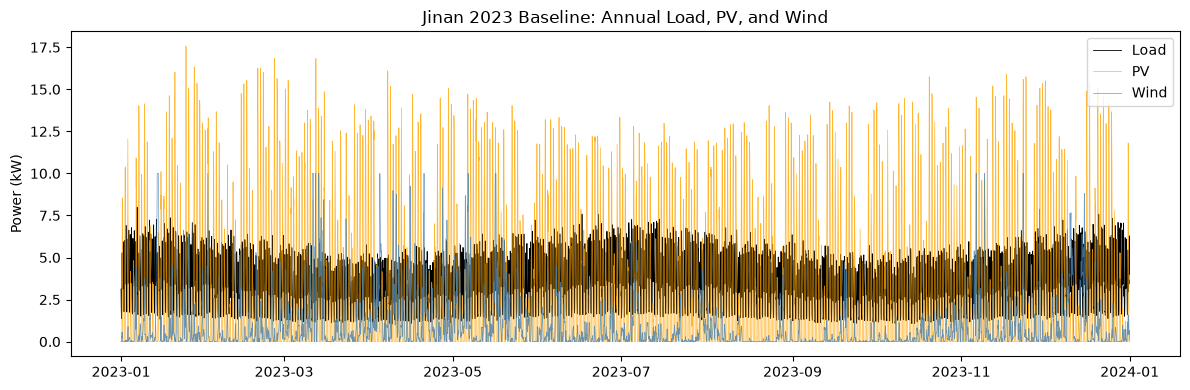

In [6]:
fig = plot_annual_profile(load, pv, wind, "Jinan 2023 Baseline: Annual Load, PV, and Wind")
save_figure(fig, FIGURES_DIR / "01_annual_profile.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/02_winter_week.png


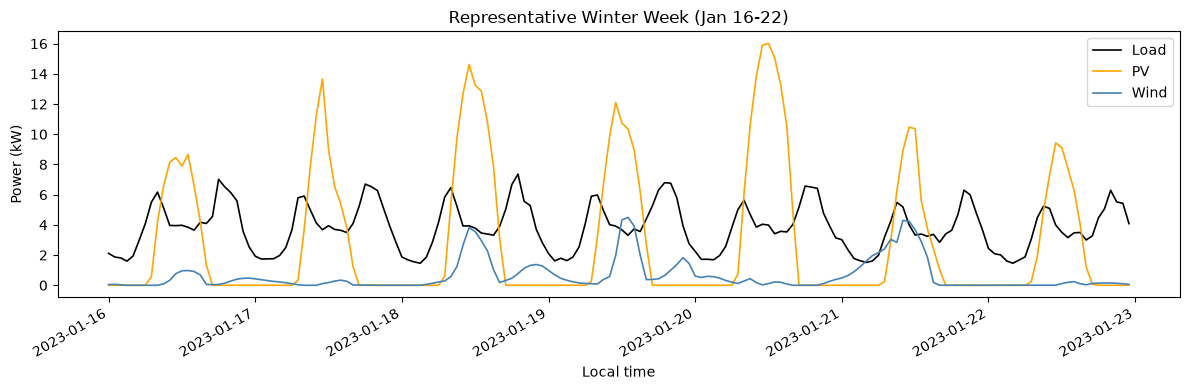

In [7]:
fig = plot_representative_week(load, pv, wind, "2023-01-16", "Representative Winter Week (Jan 16-22)")
save_figure(fig, FIGURES_DIR / "02_winter_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/03_summer_week.png


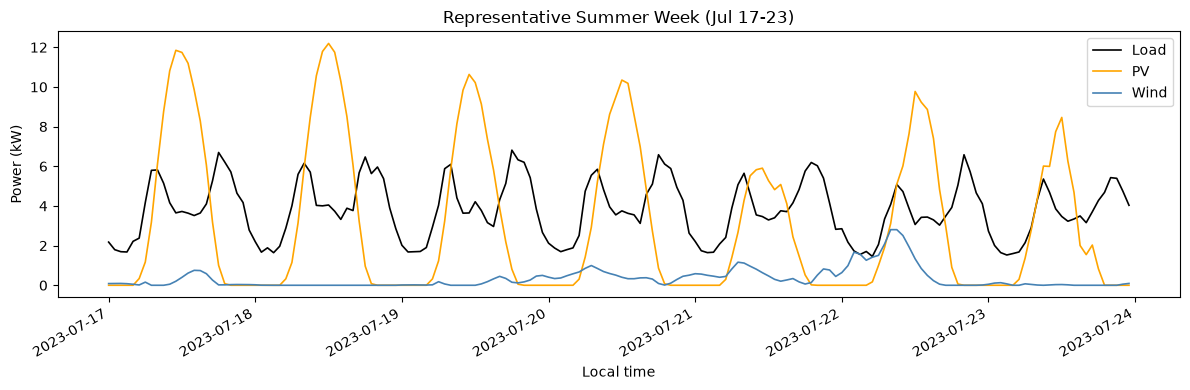

In [8]:
fig = plot_representative_week(load, pv, wind, "2023-07-17", "Representative Summer Week (Jul 17-23)")
save_figure(fig, FIGURES_DIR / "03_summer_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/04_load_duration_curve.png


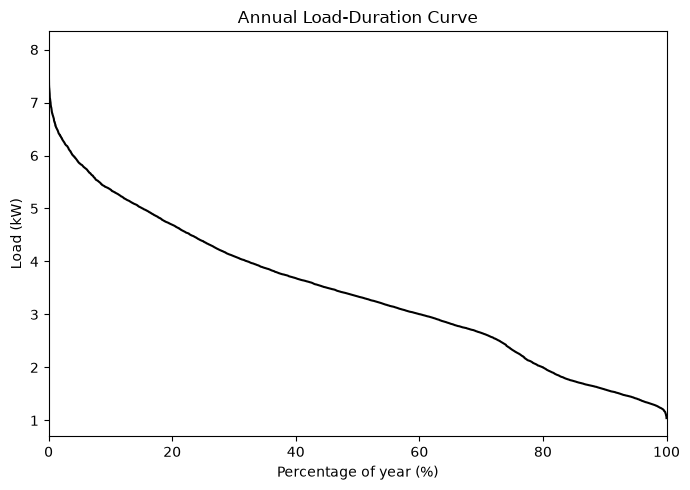

In [9]:
fig = plot_load_duration_curve(load)
save_figure(fig, FIGURES_DIR / "04_load_duration_curve.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/05_monthly_energy.png


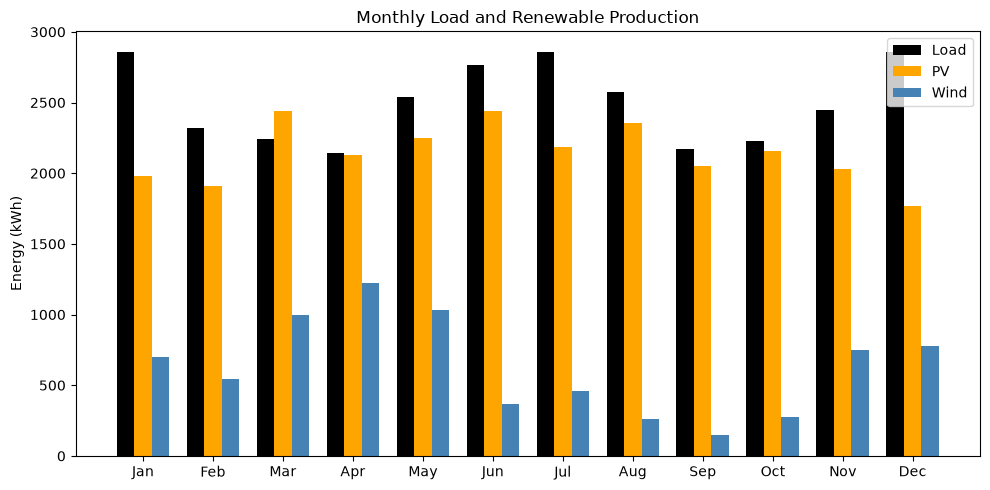

In [10]:
fig = plot_monthly_energy(load, pv, wind)
save_figure(fig, FIGURES_DIR / "05_monthly_energy.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/06_wind_speed_power_curve.png


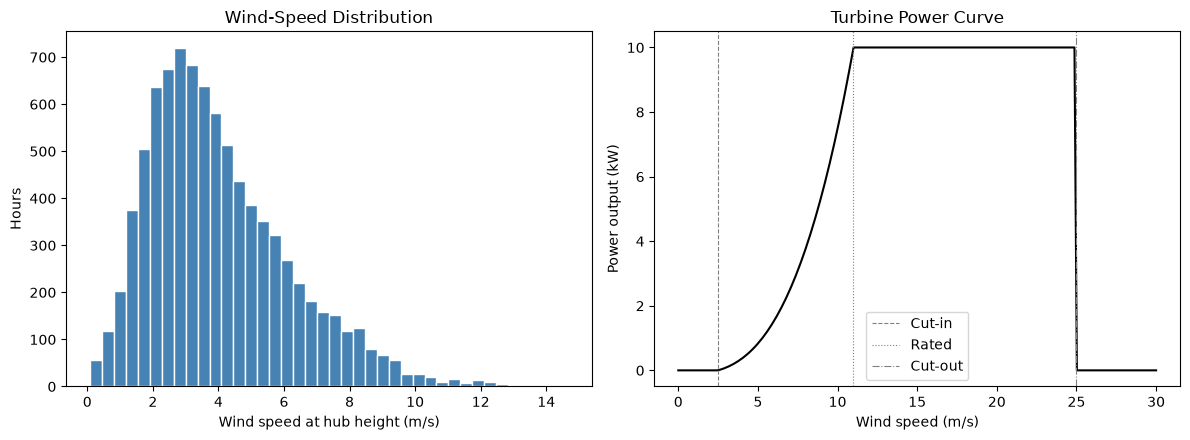

In [11]:
wind_speed_hub = adjust_wind_speed_to_hub_height(
    weather["WS10M"], config["wind"]["weather_reference_height_m"],
    config["wind"]["hub_height_m"], config["wind"]["wind_shear_exponent"],
)
fig = plot_wind_speed_distribution_and_power_curve(
    wind_speed_hub, config["wind"]["rated_power_kw"], config["wind"]["cut_in_mps"],
    config["wind"]["rated_mps"], config["wind"]["cut_out_mps"],
)
save_figure(fig, FIGURES_DIR / "06_wind_speed_power_curve.png")

## Next steps

Battery dispatch (`src.physics.dispatch`) and the exhaustive battery-size search (`src.physics.optimization`, Stage 3) will extend this notebook with: LPSP/curtailment/cost vs. battery capacity, representative SOC profiles, and the annual energy-flow balance (figures 7-11).

## Battery-size optimization (Stage 3)

Exhaustive search over the configured candidate module range (`config/jinan.yaml` -> `battery.candidate_module_counts`, 0-30 modules) against the fixed baseline PV (20 kWp) and wind (10 kW) capacities, targeting the baseline reliability requirement (LPSP <= 1%, `config/jinan.yaml` -> `reliability.primary_lpsp_target`).

In [12]:
from src.physics.optimization import run_battery_search

battery_cfg = config["battery"]
search_result = run_battery_search(
    pv, wind, load,
    n_max=battery_cfg["candidate_module_counts"]["max"],
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    installed_cost_eur_per_kwh=battery_cfg["installed_cost_eur_per_kwh"],
    economic_lifetime_years=battery_cfg["economic_lifetime_years"],
    project_lifetime_years=battery_cfg["project_lifetime_years"],
    real_discount_rate=config["economics"]["real_discount_rate"],
    lpsp_target=config["reliability"]["primary_lpsp_target"],
    reliability_sensitivity_targets=config["reliability"]["sensitivity_targets_load_served"],
)

print(f"Feasible within tested range: {search_result.feasible}")
if search_result.feasible:
    print(f"Optimal: {search_result.optimal_n_modules} modules "
          f"({search_result.optimal_capacity_kwh:.1f} kWh), LPSP={search_result.lpsp:.4f}")
else:
    print(search_result.infeasibility_reason)
print(f"Search runtime: {search_result.search_runtime_seconds:.2f} s "
      f"for {len(search_result.candidates)} candidates "
      f"({search_result.search_runtime_seconds / len(search_result.candidates):.4f} s/candidate)")

search_result.candidates.to_csv(TABLES_DIR / "baseline_battery_candidate_results.csv", index=False)
search_result.reliability_sensitivity.to_csv(TABLES_DIR / "baseline_reliability_sensitivity.csv", index=False)
search_result.candidates[["n_modules", "nominal_battery_capacity_kwh", "lpsp", "load_served_fraction",
                          "unserved_energy_kwh", "curtailed_energy_kwh", "equivalent_annual_cost_eur"]]

Feasible within tested range: False
No feasible battery size was found within the tested range for the selected fixed PV and wind capacities. Battery-range inadequacy: annual renewable production is sufficient overall, but no module count within the tested range (0..n_max) achieved the reliability target. Consider increasing candidate_module_counts.max and re-running.
Search runtime: 1.15 s for 31 candidates (0.0371 s/candidate)


,n_modules,nominal_battery_capacity_kwh,lpsp,load_served_fraction,unserved_energy_kwh,curtailed_energy_kwh,equivalent_annual_cost_eur
0,0,0.00,0.494533,0.505467,14835.995188,18053.082925,0.000000
1,1,15.36,0.354468,0.645532,10634.039125,13629.971280,1094.054649
2,2,30.72,0.239640,0.760360,7189.198827,10003.823598,2188.109299
3,3,46.08,0.152617,0.847383,4578.509701,7255.729782,3282.163948
4,4,61.44,0.116159,0.883841,3484.769082,6104.423866,4376.218597
5,5,76.80,0.101003,0.898997,3030.097155,5625.821838,5470.273247
6,6,92.16,0.088922,0.911078,2667.671439,5244.321084,6564.327896
7,7,107.52,0.079304,0.920696,2379.111665,4940.573954,7658.382545
8,8,122.88,0.072429,0.927571,2172.859023,4723.465909,8752.437194
9,9,138.24,0.067603,0.932397,2028.086186,4571.073449,9846.491844


### Is the fixed baseline generation adequate?

Checking the annual energy balance and the monthly renewable-to-load ratio directly, since LPSP alone doesn't distinguish "not enough energy, ever" from "enough energy overall, but poorly timed."

In [13]:
annual_renewable_kwh = pv.sum() + wind.sum()
annual_load_kwh = load.sum()
print(f"Annual renewable production: {annual_renewable_kwh:.0f} kWh")
print(f"Annual load: {annual_load_kwh:.0f} kWh")
print(f"Annual ratio: {annual_renewable_kwh / annual_load_kwh:.3f}")

monthly = pd.DataFrame({"renewable_kwh": pv + wind, "load_kwh": load}).resample("MS").sum()
monthly["ratio"] = monthly["renewable_kwh"] / monthly["load_kwh"]
monthly["ratio"]

Annual renewable production: 33217 kWh
Annual load: 30000 kWh
Annual ratio: 1.107


2023-01-01 00:00:00+08:00    0.936598
2023-02-01 00:00:00+08:00    1.059496
2023-03-01 00:00:00+08:00    1.535447
2023-04-01 00:00:00+08:00    1.563851
2023-05-01 00:00:00+08:00    1.290051
2023-06-01 00:00:00+08:00    1.013965
2023-07-01 00:00:00+08:00    0.925521
2023-08-01 00:00:00+08:00    1.015899
2023-09-01 00:00:00+08:00    1.012266
2023-10-01 00:00:00+08:00    1.090296
2023-11-01 00:00:00+08:00    1.135242
2023-12-01 00:00:00+08:00    0.891336
Freq: MS, Name: ratio, dtype: float64

**Finding:** annual renewable production (~33,200 kWh) exceeds annual load (30,000 kWh) overall, but three individual months (January, July, December) run a monthly deficit (ratio < 1). This is a **seasonal generation/load mismatch**, not a simple "not enough energy" problem -- and the search above confirms the practical consequence: within the configured 0-30 module range (up to 460.8 kWh), LPSP never drops below roughly 3%, well short of the 1% target, despite adequate annual energy and heavy curtailment (thousands of kWh/year wasted in surplus months). A battery sized for daily/weekly cycling cannot bridge a month-scale seasonal deficit.

This means: **the fixed baseline PV/wind combination (20 kWp + 10 kW) is not adequate** to reach the 99% reliability target for this load profile within the specified battery search range, and per PROJECT_BRIEF.md §12, this is reported honestly as infeasible rather than silently returning the largest-tested candidate as "optimal."

### Diagnostic-only extended search (not the baseline result)

For context only -- to characterize *how much* battery this specific seasonal mismatch would need, not to redefine the baseline -- extending the search well beyond the configured range:

In [14]:
diagnostic_result = run_battery_search(
    pv, wind, load, n_max=100,
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    installed_cost_eur_per_kwh=battery_cfg["installed_cost_eur_per_kwh"],
    economic_lifetime_years=battery_cfg["economic_lifetime_years"],
    project_lifetime_years=battery_cfg["project_lifetime_years"],
    real_discount_rate=config["economics"]["real_discount_rate"],
    lpsp_target=config["reliability"]["primary_lpsp_target"],
)
print(f"Diagnostic search feasible: {diagnostic_result.feasible}")
if diagnostic_result.feasible:
    print(f"Would require {diagnostic_result.optimal_n_modules} modules "
          f"({diagnostic_result.optimal_capacity_kwh:.1f} kWh) -- "
          f"{diagnostic_result.optimal_n_modules - battery_cfg['candidate_module_counts']['max']} "
          f"more than the configured 0-30 range.")

Diagnostic search feasible: True
Would require 62 modules (952.3 kWh) -- 32 more than the configured 0-30 range.


### Required figures (PROJECT_BRIEF.md §27, mechanistic figures 7-11)

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/07_lpsp_vs_capacity.png


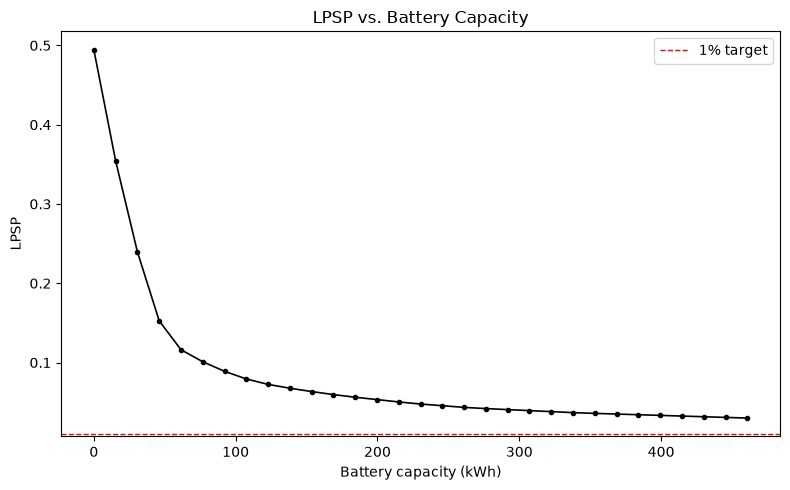

In [15]:
fig = plot_metric_vs_battery_capacity(
    search_result.candidates, "lpsp", "LPSP",
    target_line=config["reliability"]["primary_lpsp_target"], target_label="1% target",
)
save_figure(fig, FIGURES_DIR / "07_lpsp_vs_capacity.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/08_curtailment_vs_capacity.png


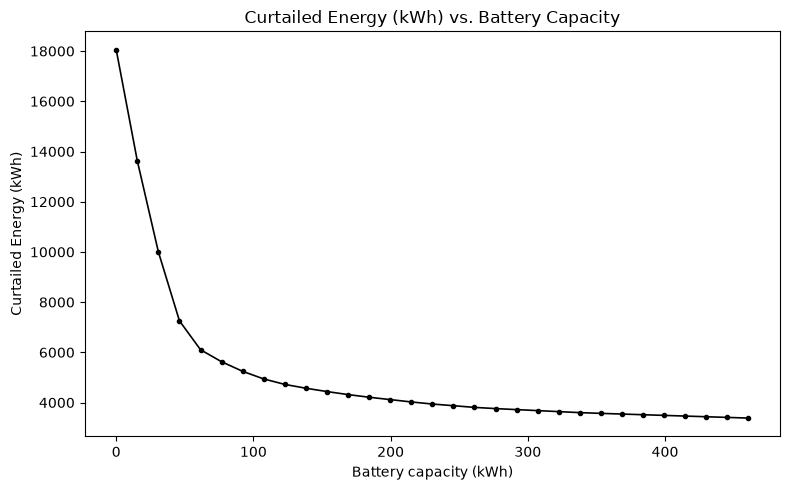

In [16]:
fig = plot_metric_vs_battery_capacity(search_result.candidates, "curtailed_energy_kwh", "Curtailed Energy (kWh)")
save_figure(fig, FIGURES_DIR / "08_curtailment_vs_capacity.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/09_cost_vs_capacity.png


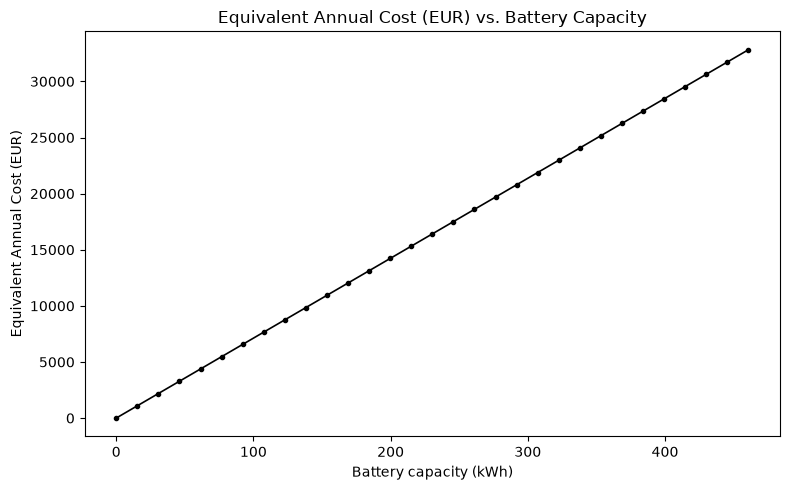

In [17]:
fig = plot_metric_vs_battery_capacity(search_result.candidates, "equivalent_annual_cost_eur", "Equivalent Annual Cost (EUR)")
save_figure(fig, FIGURES_DIR / "09_cost_vs_capacity.png")

SOC profile and energy-flow balance are illustrated using the **largest tested candidate** (n=30 modules), since the search is infeasible within the configured range and there is no "optimal" dispatch to show instead.

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/10_soc_profile.png


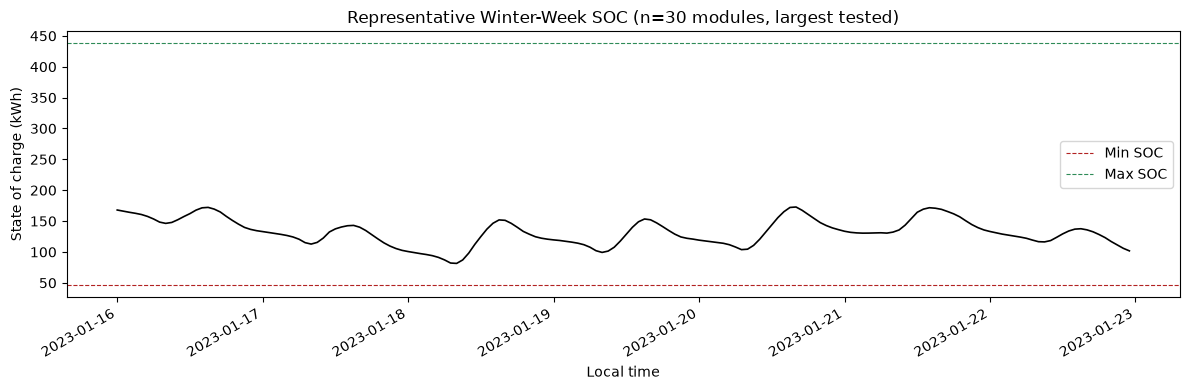

In [18]:
from src.physics.battery import BatterySpec
from src.physics.dispatch import resolve_initial_soc_bias
from src.visualization.plotting import plot_soc_profile, plot_energy_flow_balance

largest_tested_battery = BatterySpec(
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    n_modules=battery_cfg["candidate_module_counts"]["max"],
)
largest_tested_dispatch = resolve_initial_soc_bias(pv, wind, load, largest_tested_battery)
largest_tested_dispatch.to_csv(TABLES_DIR / "baseline_largest_tested_hourly_dispatch.csv", index_label="timestamp")

fig = plot_soc_profile(
    largest_tested_dispatch, "2023-01-16",
    largest_tested_battery.min_soc_kwh, largest_tested_battery.max_soc_kwh,
    f"Representative Winter-Week SOC (n={largest_tested_battery.n_modules} modules, largest tested)",
)
save_figure(fig, FIGURES_DIR / "10_soc_profile.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/11_energy_flow_balance.png


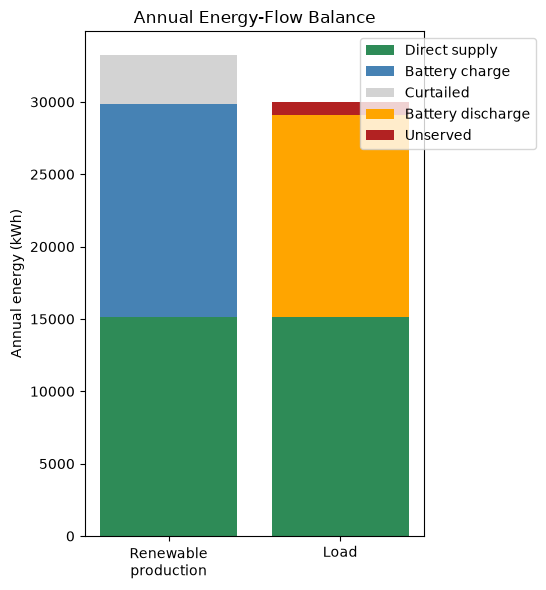

In [19]:
fig = plot_energy_flow_balance(largest_tested_dispatch)
save_figure(fig, FIGURES_DIR / "11_energy_flow_balance.png")

## Stage 3 summary

- The mechanistic exhaustive search correctly implements PROJECT_BRIEF.md §12: it never labels an infeasible candidate "optimal," and distinguishes renewable-generation inadequacy from battery-range inadequacy.
- **Result: the baseline fixed PV/wind capacities (20 kWp + 10 kW) do not meet the 99% reliability target within the configured 0-30 module range**, due to a seasonal (monthly-scale) mismatch between generation and load, not an annual energy shortfall.
- This is reported honestly rather than silently accepted, per the refinement addendum's repeated instruction not to hide negative or inconclusive mechanistic/AI results.

**Open question for Stage 4 (scenario generation):** scenarios sampled with fixed PV/wind ranges similar to this baseline may frequently be infeasible within a 0-30 module search range. The scenario sampler (`src.scenarios.sampling`) must handle this by labelling infeasible scenarios explicitly (never substituting an arbitrary large capacity), per PROJECT_BRIEF.md §14 -- but a very high infeasible-scenario rate would reduce the usable pilot dataset size and needs to be checked once Stage 4 begins.